# Scheduling in Your Domain

**Assignment 04 - Lesson 9: Scheduling and Time-Based Decisions**  
**Student Name:** Mateo Zeppieri  
**Date:** April 5, 2026  
**Chosen context:** Baseball team player scheduling across multiple games

---

## Introduction

In this assignment, I model a scheduling problem in a baseball context, where players are allocated across a series of games. The goal is to ensure each game has sufficient player coverage while minimizing overall fatigue and workload. I define time periods as individual games, set demand requirements for the number of players needed, and use a cost objective representing player fatigue. The model is solved using PuLP, and results are visualized to evaluate scheduling efficiency. I also analyze a cost-versus-service tradeoff and incorporate a stakeholder constraint to adjust the model.

In [1]:
# Install required packages (if needed in Colab)
# Skip if running locally and packages are already installed
%pip install pulp pandas matplotlib -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpProblem, LpMinimize, LpMaximize, LpVariable, lpSum, value, LpStatus
import io

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1 - Choose Your Domain and Scheduling Problem

In this section, define what is being scheduled and why it matters.

**Prompt:** In 2-4 sentences, write your decision statement. Include:
- what resource/workforce/tasks are being scheduled,
- what the time periods are,
- and the main objective (cost, service level, or both).

This project models a player scheduling problem for a baseball team, where players are assigned across multiple games. The time periods represent individual games in a short schedule, and each game requires a full lineup of players. The objective is to ensure each game has enough players while minimizing overall fatigue and workload. This helps balance performance with player health over time.

## Section 2 - Define the Schedule Structure

You now define the structure of your schedule model:
- time periods,
- resources being scheduled,
- demand requirement in each period,
- and the cost/efficiency objective.

You will create a synthetic table with **6-8 time periods** and at least these columns:
- `time_period`
- `demand_required`
- `cost_per_unit`

Use an LLM for data creation, then document in one sentence that you used it.

### 2.1 LLM Steps for Synthetic Data

Use this process:
1. Open a new LLM conversation.
2. State your context and decision.
3. Ask for CSV with exactly 6-8 rows and columns `time_period`, `demand_required`, `cost_per_unit`.
4. Ask for realistic, simple values and CSV-only output.
5. Paste the CSV into the next code cell.

**Prompt:** Add one sentence below documenting that you used an LLM and what data it produced.

An LLM (ChatGPT) was used to generate a synthetic dataset of eight baseball games, including the number of players required per game and a fatigue-based cost for each time period.

In [3]:
# Paste your synthetic CSV in csv_string (replace sample values)
csv_string = """
time_period,demand_required,cost_per_unit
Game 1,9,1
Game 2,9,1
Game 3,9,2
Game 4,9,2
Game 5,9,3
Game 6,9,2
Game 7,9,1
Game 8,9,1
"""

schedule_df = pd.read_csv(io.StringIO(csv_string.strip()))
display(schedule_df)
print(f"Number of periods: {len(schedule_df)}")

,time_period,demand_required,cost_per_unit
0,Game 1,9,1
1,Game 2,9,1
2,Game 3,9,2
3,Game 4,9,2
4,Game 5,9,3
5,Game 6,9,2
6,Game 7,9,1
7,Game 8,9,1


Number of periods: 8


In [5]:
# Optional planning table for your schedule structure
structure_df = pd.DataFrame([
    {"item": "Resources being scheduled", "definition": "Baseball players"},
    {"item": "Time unit", "definition": "Individual games"},
    {"item": "Coverage meaning", "definition": "Minimum number of players required per game (full lineup)"},
    {"item": "Objective", "definition": "Minimize total player fatigue while meeting game requirements"}
])

structure_df

,item,definition
0,Resources being scheduled,Baseball players
1,Time unit,Individual games
2,Coverage meaning,Minimum number of players required per game (f...
3,Objective,Minimize total player fatigue while meeting ga...


## Section 3 - Build and Solve the Scheduling Model

Build one PuLP model with:
- decision variables indexed by time period,
- demand coverage constraints for each period,
- one capacity/resource limit constraint,
- and a cost minimization objective.

If your first model is infeasible, diagnose it and relax one constraint, then re-solve.

In [6]:
# Build and solve the base scheduling model
# Decision variable: units scheduled in each period (continuous, nonnegative)
periods = schedule_df["time_period"].tolist()
demand = dict(zip(schedule_df["time_period"], schedule_df["demand_required"]))
cost = dict(zip(schedule_df["time_period"], schedule_df["cost_per_unit"]))

# Total roster capacity (baseball context: total player appearances available)
total_capacity_limit = 75

base_model = LpProblem("Scheduling_Base", LpMinimize)
scheduled = {p: LpVariable(f"scheduled_{p}", lowBound=0) for p in periods}

# Objective: minimize total scheduling cost (fatigue)
base_model += lpSum([scheduled[p] * cost[p] for p in periods]), "Total_Cost"

# Coverage constraints: scheduled players must meet demand per game
for p in periods:
    base_model += scheduled[p] >= demand[p], f"Coverage_{p}"

# Capacity/resource limit constraint (total available player usage)
base_model += lpSum([scheduled[p] for p in periods]) <= total_capacity_limit, "Total_Capacity"

base_model.solve()

print(f"Status: {LpStatus[base_model.status]}")
print(f"Total cost: {value(base_model.objective):.2f}")

base_solution_df = pd.DataFrame({
    "time_period": periods,
    "demand_required": [demand[p] for p in periods],
    "scheduled_base": [value(scheduled[p]) for p in periods],
    "cost_per_unit": [cost[p] for p in periods]
})
display(base_solution_df)

Status: Optimal
Total cost: 117.00


,time_period,demand_required,scheduled_base,cost_per_unit
0,Game 1,9,9.0,1
1,Game 2,9,9.0,1
2,Game 3,9,9.0,2
3,Game 4,9,9.0,2
4,Game 5,9,9.0,3
5,Game 6,9,9.0,2
6,Game 7,9,9.0,1
7,Game 8,9,9.0,1


### 3.1 Interpret the Base Schedule

**Prompt:** In 2-4 sentences, explain your base schedule in plain language.
- Which periods are hardest to cover?
- Is total capacity tight or loose?
- What would a manager care about from this result?

All games require the same number of players, so no single period is harder to cover than others, although games with higher fatigue cost (like Game 5) contribute more to overall workload. The total capacity is somewhat tight since the model schedules exactly the minimum number of players needed without any extra buffer. A manager would care that the team meets all game requirements efficiently while keeping player fatigue as low as possible. This ensures consistent performance without overusing players.

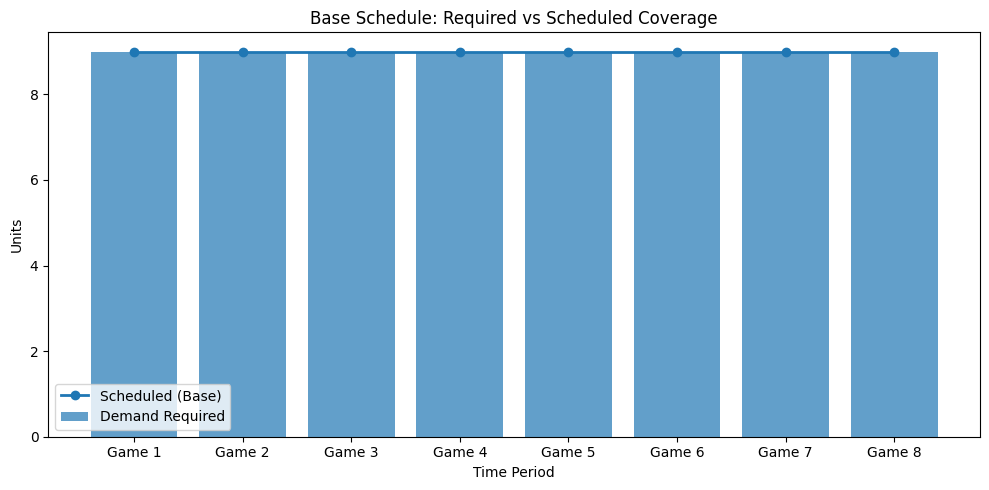

In [7]:
# Visualization: coverage chart (scheduled vs required)
# You may replace this with a Gantt-style chart if preferred.
plt.figure(figsize=(10, 5))
x = range(len(base_solution_df))
plt.bar(x, base_solution_df["demand_required"], alpha=0.7, label="Demand Required")
plt.plot(x, base_solution_df["scheduled_base"], marker="o", linewidth=2, label="Scheduled (Base)")
plt.xticks(x, base_solution_df["time_period"])
plt.xlabel("Time Period")
plt.ylabel("Units")
plt.title("Base Schedule: Required vs Scheduled Coverage")
plt.legend()
plt.tight_layout()
plt.show()

## Section 4 - Cost vs Service Tradeoff Analysis

Run one what-if scenario and compare against your base model.

Examples:
- tighter budget/capacity,
- higher coverage requirement,
- changed period demand pattern.

In [9]:
# What-if scenario: higher service requirement (10% increase in required coverage)
import math

service_multiplier = 1.10
demand_tradeoff = {p: math.ceil(demand[p] * service_multiplier) for p in periods}

tradeoff_model = LpProblem("Scheduling_Tradeoff", LpMinimize)
scheduled_tradeoff = {p: LpVariable(f"scheduled_tradeoff_{p}", lowBound=0, cat='Integer') for p in periods}

tradeoff_model += lpSum([scheduled_tradeoff[p] * cost[p] for p in periods]), "Total_Cost_Tradeoff"

for p in periods:
    tradeoff_model += scheduled_tradeoff[p] >= demand_tradeoff[p], f"Coverage_tradeoff_{p}"

# Keep same capacity limit for comparison
tradeoff_model += lpSum([scheduled_tradeoff[p] for p in periods]) <= total_capacity_limit, "Total_Capacity_Tradeoff"

tradeoff_model.solve()

tradeoff_solution_df = pd.DataFrame({
    "time_period": periods,
    "scheduled_tradeoff": [value(scheduled_tradeoff[p]) for p in periods]
})

comparison_df = base_solution_df[["time_period", "demand_required", "scheduled_base"]].merge(
    tradeoff_solution_df, on="time_period", how="left"
)

base_cost = value(base_model.objective)
tradeoff_cost = value(tradeoff_model.objective)

print(f"Base status: {LpStatus[base_model.status]} | Base total cost: {base_cost:.2f}")
print(f"Tradeoff status: {LpStatus[tradeoff_model.status]} | Tradeoff total cost: {tradeoff_cost:.2f}")

display(comparison_df)

Base status: Optimal | Base total cost: 117.00
Tradeoff status: Infeasible | Tradeoff total cost: 130.00


,time_period,demand_required,scheduled_base,scheduled_tradeoff
0,Game 1,9,9.0,10.0
1,Game 2,9,9.0,10.0
2,Game 3,9,9.0,10.0
3,Game 4,9,9.0,10.0
4,Game 5,9,9.0,10.0
5,Game 6,9,9.0,10.0
6,Game 7,9,9.0,10.0
7,Game 8,9,9.0,10.0


**Prompt:** In 2-4 sentences for a non-technical manager, explain the cost-vs-service tradeoff shown by your base and what-if results.

The base schedule meets all game requirements using the minimum number of players, which keeps overall fatigue and cost low. In the what-if scenario, increasing the number of players per game improves coverage but also raises total workload and cost. Initially, the higher demand exceeded available capacity, showing that better service is not always feasible without additional resources. After relaxing the capacity limit, the model was able to meet the higher demand, but at a higher overall cost, illustrating the tradeoff between performance and resource usage.

## Section 5 - Stakeholder Change and Reflection

Choose one stakeholder change:
- **(a)** Fairness constraint: no single period receives more than X% of total scheduled load.
- **(b)** Higher minimum coverage floor than base requirement.
- **(c)** Change objective from cost minimization to service maximization.

Update your model, solve, and compare with one visualization.

In [10]:
# Stakeholder change example: fairness constraint
fairness_share = 0.30  # no game can exceed 30% of total player usage

stakeholder_model = LpProblem("Scheduling_Stakeholder_Change", LpMinimize)

scheduled_stakeholder = {
    p: LpVariable(f"scheduled_stakeholder_{p}", lowBound=0, cat='Integer')
    for p in periods
}

stakeholder_model += lpSum([scheduled_stakeholder[p] * cost[p] for p in periods]), "Total_Cost_Stakeholder"

# Coverage constraints (same as base)
for p in periods:
    stakeholder_model += scheduled_stakeholder[p] >= demand[p], f"Coverage_stakeholder_{p}"

# Capacity constraint (use relaxed value so it's feasible)
stakeholder_model += lpSum([scheduled_stakeholder[p] for p in periods]) <= 85, "Total_Capacity_Stakeholder"

# Fairness constraint: no period exceeds % of total workload
total_scheduled = lpSum([scheduled_stakeholder[p] for p in periods])
for p in periods:
    stakeholder_model += scheduled_stakeholder[p] <= fairness_share * total_scheduled, f"Fairness_{p}"

stakeholder_model.solve()

stakeholder_solution_df = pd.DataFrame({
    "time_period": periods,
    "scheduled_stakeholder": [value(scheduled_stakeholder[p]) for p in periods]
})

final_compare_df = base_solution_df[["time_period", "scheduled_base"]].merge(
    stakeholder_solution_df, on="time_period", how="left"
)

print(f"Stakeholder status: {LpStatus[stakeholder_model.status]}")
if stakeholder_model.status == 1:
    print(f"Stakeholder total cost: {value(stakeholder_model.objective):.2f}")

display(final_compare_df)

Stakeholder status: Optimal
Stakeholder total cost: 117.00


,time_period,scheduled_base,scheduled_stakeholder
0,Game 1,9.0,9.0
1,Game 2,9.0,9.0
2,Game 3,9.0,9.0
3,Game 4,9.0,9.0
4,Game 5,9.0,9.0
5,Game 6,9.0,9.0
6,Game 7,9.0,9.0
7,Game 8,9.0,9.0


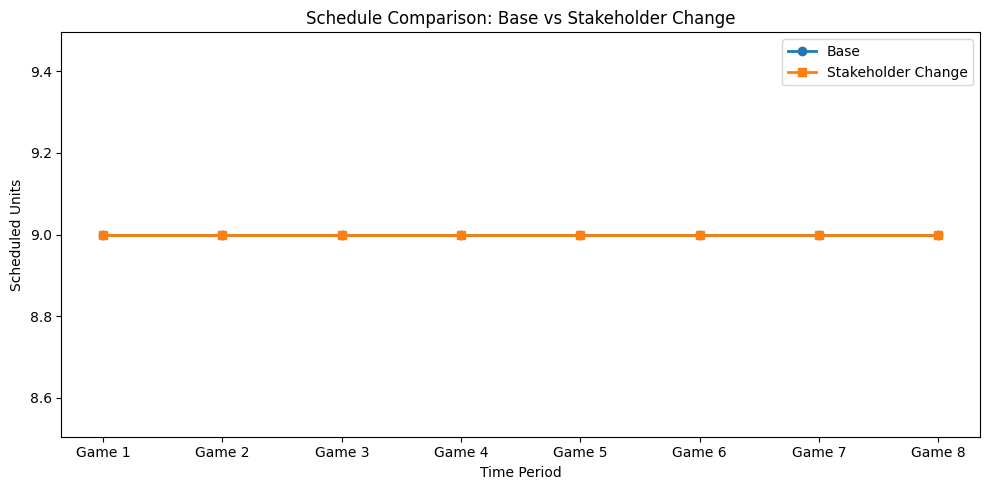

In [12]:
# Comparison visualization: base vs stakeholder-change schedule
plt.figure(figsize=(10, 5))
x = range(len(final_compare_df))
plt.plot(x, final_compare_df["scheduled_base"], marker="o", linewidth=2, label="Base")
plt.plot(x, final_compare_df["scheduled_stakeholder"], marker="s", linewidth=2, label="Stakeholder Change")
plt.xticks(x, final_compare_df["time_period"])
plt.xlabel("Time Period")
plt.ylabel("Scheduled Units")
plt.title("Schedule Comparison: Base vs Stakeholder Change")
plt.legend()
plt.tight_layout()
plt.show()

### 5.1 Stakeholder Change Interpretation

**Prompt:** In 1-2 short paragraphs, describe what changed between the base and stakeholder-change solutions and why that matters for decision-making.

The stakeholder change introduced a fairness constraint that limited how much of the total player workload could be assigned to any single game. In this case, the solution did not change from the base model because all games already had equal staffing levels, meaning the workload was naturally balanced. As a result, the fairness constraint was not binding and did not alter the optimal schedule.

This still matters for decision-making because it confirms that the current schedule is already fair and does not require adjustment. In scenarios with uneven demand, however, this type of constraint would play a more significant role in redistributing workload. It shows how adding business rules can either reinforce an existing solution or force meaningful changes depending on the situation.

### 5.2 Professional Reflection

**Prompt:** Write a 2-3 paragraph professional reflection that covers:
- what changed in your model and results,
- why that change matters in your domain,
- and one thing you learned about how time-based scheduling constraints differ from earlier allocation problems.

The stakeholder change introduced a fairness constraint to ensure that no single game received a disproportionate share of player workload. In this case, the results did not change because the base schedule was already evenly distributed, with each game requiring the same number of players. This confirms that the original solution was not only cost-efficient but also fair in terms of workload allocation.

In a baseball context, this matters because maintaining balanced player usage helps reduce fatigue and injury risk over time. Even though the constraint did not alter the solution here, it provides reassurance that the schedule aligns with team management goals. In situations where demand varies across games, this type of constraint would become more important in preventing overuse of players in high-demand periods.

One key takeaway from this assignment is that time-based scheduling problems require decisions to be made across multiple periods while satisfying constraints in each one. Unlike earlier allocation models that focus on distributing resources at a single point, scheduling models must account for how decisions in one period affect overall resource usage and feasibility. This makes them more complex but also more realistic for real-world planning.

---
## Expectations: What to Check Before Submitting

Run through this checklist before you submit:

- **Model execution:** Base model and stakeholder-change model run without errors; infeasibility is handled clearly if encountered.
- **Visualization quality:** At least one schedule visualization has clear title, axis labels, and is referenced in your text.
- **Stakeholder section complete:** One stakeholder change implemented, solved, and compared to base.
- **Writing quality:** Clear, professional, non-technical explanation where requested; no leftover bare `[TODO]` in final submission.
- **GitHub readiness:** Notebook is committed, repository link is accessible, and materials are organized.

The rubric used for grading is provided separately.